In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
df = pd.read_csv("powerplant_data.csv")

In [19]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [20]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [21]:
X = df.drop(columns="PE")
y = df["PE"]

In [22]:
X.shape

(9568, 4)

In [23]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [24]:
scaler = StandardScaler()
scaler.fit(X_train)
X_scaled_train = scaler.transform(X_train)
X_scaled_test = scaler.transform(X_test)

# Pytorch implementation

In [25]:
import torch
import torch.nn as nn

In [26]:
X_scaled_train = torch.tensor(X_scaled_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_scaled_test = torch.tensor(X_scaled_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [27]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_scaled_train, y_train)
test_dataset = TensorDataset(X_scaled_test, y_test)

In [28]:
train_loader = DataLoader(train_dataset, batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# DEEP Learning

In [52]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
             # 1 hidden layer
            nn.Linear(4,6),
            nn.ReLU(),

            # 2 hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)

In [53]:
import torch.optim as optim

model = ANN()

#loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Train ANN

In [54]:
epochs = 50
train_losses = []
validation_losses = []
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb,yb in train_loader:

        optimizer.zero_grad()
        outputs = model(xb) # forward propagation gives the output
        loss = criterion(outputs,yb) # calculate the loss using MSE
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        running_loss += loss.item() # conver loss tensor value to float value

    epoch_training_loss = running_loss / len(train_loader)
    train_losses.append(epoch_training_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_loss += loss.item()

    epoch_testing_loss = running_val_loss / len(test_loader)
    validation_losses.append(epoch_testing_loss)

    if epoch_testing_loss < best_val_loss:
        best_val_loss = epoch_testing_loss
        torch.save(model.state_dict(),"best_params.pt")

    # printing both losses
    print(f"epoch {epoch+1}/{epochs} ==> Training Loss = {epoch_training_loss} && Validation Loss = {epoch_testing_loss}")

epoch 1/50 ==> Training Loss = 205958.83033854168 && Validation Loss = 204439.97239583332
epoch 2/50 ==> Training Loss = 199939.92825520833 && Validation Loss = 192208.84036458333
epoch 3/50 ==> Training Loss = 178235.95598958334 && Validation Loss = 160444.43463541666
epoch 4/50 ==> Training Loss = 137670.59674479166 && Validation Loss = 113329.71471354166
epoch 5/50 ==> Training Loss = 89287.81806640625 && Validation Loss = 67022.78489583333
epoch 6/50 ==> Training Loss = 50244.401700846356 && Validation Loss = 37195.51549479167
epoch 7/50 ==> Training Loss = 29671.426708984374 && Validation Loss = 24660.087451171876
epoch 8/50 ==> Training Loss = 21818.092199707033 && Validation Loss = 19824.529817708335
epoch 9/50 ==> Training Loss = 18196.234334309895 && Validation Loss = 16705.537255859374
epoch 10/50 ==> Training Loss = 15247.04493408203 && Validation Loss = 13886.958756510418
epoch 11/50 ==> Training Loss = 12550.171177164713 && Validation Loss = 11221.188598632812
epoch 12/50 

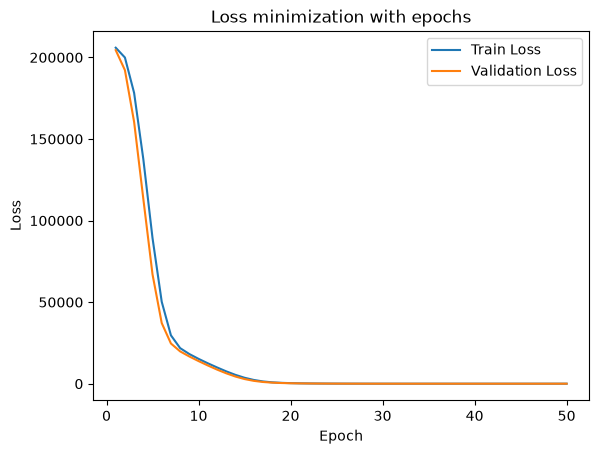

In [56]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots()
ax.plot([x for x in range(1,51)],train_losses,label="Train Loss")
ax.plot([x for x in range(1,51)],validation_losses, label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss minimization with epochs")
plt.legend()
plt.show()

In [57]:
# Loading the file
model.load_state_dict(torch.load("best_params.pt"))

<All keys matched successfully>

In [58]:
#Evaluation
model.eval()
with torch.no_grad():
    train_preds = model(X_scaled_train)
    test_preds = model(X_scaled_test)

    train_mse_loss = criterion(train_preds,y_train)
    test_mse_loss = criterion(test_preds,y_test)

print("Train MSE LOSS", train_mse_loss.item())
print("Test MSE LOSS",test_mse_loss.item())

Train MSE LOSS 20.967060089111328
Test MSE LOSS 19.16035270690918


In [59]:
# R2 score
from sklearn.metrics import r2_score
print("r2 score: ",r2_score(y_test, test_preds))

r2 score:  0.9330394864082336
